In [ ]:
import pandas as pd

In [ ]:
# Carga de cada Excel en un DataFrame
df_paro_raw = pd.read_excel("paroporCCAA2025.xlsx")
df_poblacion_raw = pd.read_excel("poblacionCCAA2025.xlsx")
df_mayores65_raw = pd.read_excel("poblacionmayor65CCAA2025.xlsx")
df_pib_ccaa_raw = pd.read_excel("pibPorCCAA2024.xlsx")
df_pib_capita_ccaa_raw = pd.read_excel("pibPerCapitaCCAA2024.xlsx")
df_renta_raw = pd.read_excel("rentaAnualNetaMediaHogarCCAA2025.xlsx")
df_pobreza_raw = pd.read_excel("tasaRiesgoPobreza2025.xlsx")
df_dependencia_ccaa_raw = pd.read_excel("tasaDependenciaCCAA2025.xlsx")
df_esperanza_vida_ccaa_raw = pd.read_excel("esperanzaVidaCCAA2024.xlsx")


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

## Transformaciones DFs

In [ ]:
df_paro = df_paro_raw.iloc[8:27].copy()
df_paro = df_paro.iloc[:, :5]
df_paro.columns = [
    "Comunidad_Autonoma",
    "T4",
    "T3",
    "T2",
    "T1"
]

# Comunidad Autónoma como texto
df_paro["Comunidad_Autonoma"] = df_paro["Comunidad_Autonoma"].astype(str)

# Trimestres como float
for col in ["T4", "T3", "T2", "T1"]:
    df_paro[col] = pd.to_numeric(df_paro[col], errors="coerce")


# Calcular media anual
df_paro["Paro_medio"] = df_paro[["T4", "T3", "T2", "T1"]].mean(axis=1)
df_paro["Paro_medio"] = df_paro["Paro_medio"].round(2)
df_paro = df_paro[["Comunidad_Autonoma", "Paro_medio"]]

# Asegurar tipo float
df_paro["Paro_medio"] = df_paro["Paro_medio"].astype(float)


# Mostrar las primeras filas de cada uno
print("=== PARO ===")
display(df_paro)
df_paro.dtypes

=== PARO ===


,Comunidad_Autonoma,Paro_medio
8,01 Andalucía,15.23
9,02 Aragón,8.04
10,"03 Asturias, Principado de",8.83
11,"04 Balears, Illes",8.94
12,05 Canarias,13.52
13,06 Cantabria,7.34
14,07 Castilla y León,8.55
15,08 Castilla - La Mancha,12.77
16,09 Cataluña,8.36
17,10 Comunitat Valenciana,11.57


,0
Comunidad_Autonoma,object
Paro_medio,float64


In [ ]:
df_poblacion = df_poblacion_raw.iloc[7:26, :2].copy()
df_poblacion.columns = [
    "Comunidad_Autonoma",
    "Poblacion"
]

df_poblacion["Comunidad_Autonoma"] = df_poblacion["Comunidad_Autonoma"].astype(str)
df_poblacion["Poblacion"] = df_poblacion["Poblacion"].astype("int64")

print("=== POBLACIÓN ===")
display(df_poblacion)
df_poblacion.dtypes

=== POBLACIÓN ===


,Comunidad_Autonoma,Poblacion
7,01 Andalucía,8676713
8,02 Aragón,1364621
9,"03 Asturias, Principado de",1015128
10,"04 Balears, Illes",1249844
11,05 Canarias,2258866
12,06 Cantabria,593623
13,07 Castilla y León,2401221
14,08 Castilla - La Mancha,2126378
15,09 Cataluña,8124126
16,10 Comunitat Valenciana,5425182


,0
Comunidad_Autonoma,object
Poblacion,int64


In [ ]:
df_mayores65 = df_mayores65_raw.iloc[7:26, :2].copy()

df_mayores65.columns = [
    "Comunidad_Autonoma",
    "Porcentaje_Mayores_65"
]

# Tipos
df_mayores65["Comunidad_Autonoma"] = (
    df_mayores65["Comunidad_Autonoma"]
    .astype(str)
)

df_mayores65["Porcentaje_Mayores_65"] = (
    pd.to_numeric(
        df_mayores65["Porcentaje_Mayores_65"],
        errors="coerce"
    )
    .astype(float)
)

print("=== MAYORES DE 65 ===")
display(df_mayores65)

df_mayores65.info()

=== MAYORES DE 65 ===


,Comunidad_Autonoma,Porcentaje_Mayores_65
7,01 Andalucía,19.13
8,02 Aragón,22.60
9,"03 Asturias, Principado de",28.36
10,"04 Balears, Illes",16.84
11,05 Canarias,18.19
12,06 Cantabria,24.52
13,07 Castilla y León,27.25
14,08 Castilla - La Mancha,20.08
15,09 Cataluña,19.72
16,10 Comunitat Valenciana,20.39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 7 to 25
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Comunidad_Autonoma     19 non-null     object 
 1   Porcentaje_Mayores_65  19 non-null     float64
dtypes: float64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_renta = df_renta_raw.iloc[7:26, :2].copy()

df_renta.columns = [
    "Comunidad_Autonoma",
    "Renta_Media_Hogar"
]

df_renta["Comunidad_Autonoma"] = df_renta["Comunidad_Autonoma"].astype(str)

df_renta["Renta_Media_Hogar"] = pd.to_numeric(
    df_renta["Renta_Media_Hogar"],
    errors="coerce"
).astype("int64")

print("=== RENTA ===")
display(df_renta)

df_renta.info()

=== RENTA ===


,Comunidad_Autonoma,Renta_Media_Hogar
7,01 Andalucía,33078
8,02 Aragón,39943
9,"03 Asturias, Principado de",36869
10,"04 Balears, Illes",44457
11,05 Canarias,37023
12,06 Cantabria,38022
13,07 Castilla y León,35011
14,08 Castilla - La Mancha,33499
15,09 Cataluña,43889
16,10 Comunitat Valenciana,34682


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 7 to 25
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Comunidad_Autonoma  19 non-null     object
 1   Renta_Media_Hogar   19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_pobreza = df_pobreza_raw.iloc[7:26, :2].copy()

df_pobreza.columns = [
    "Comunidad_Autonoma",
    "Tasa_Riesgo_Pobreza"
]

df_pobreza["Comunidad_Autonoma"] = df_pobreza["Comunidad_Autonoma"].astype(str)

df_pobreza["Tasa_Riesgo_Pobreza"] = pd.to_numeric(
    df_pobreza["Tasa_Riesgo_Pobreza"],
    errors="coerce"
).astype("float64")

print("=== POBREZA ===")
display(df_pobreza)

df_pobreza.info()

=== POBREZA ===


,Comunidad_Autonoma,Tasa_Riesgo_Pobreza
7,01 Andalucía,27.7
8,02 Aragón,13.6
9,"03 Asturias, Principado de",17.2
10,"04 Balears, Illes",11.6
11,05 Canarias,22.9
12,06 Cantabria,13.9
13,07 Castilla y León,19.8
14,08 Castilla - La Mancha,25.9
15,09 Cataluña,14.3
16,10 Comunitat Valenciana,26.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 7 to 25
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comunidad_Autonoma   19 non-null     object 
 1   Tasa_Riesgo_Pobreza  19 non-null     float64
dtypes: float64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_pib_ccaa = df_pib_ccaa_raw.iloc[5:24, :2].copy()

df_pib_ccaa.columns = [
    "Comunidad_Autonoma",
    "PIB"
]

df_pib_ccaa["Comunidad_Autonoma"] = df_pib_ccaa["Comunidad_Autonoma"].astype(str)

# Pasamos de miles de € a millones de €
df_pib_ccaa["PIB"] = (df_pib_ccaa["PIB"] / 1000).round(3)

df_pib_ccaa["PIB"] = pd.to_numeric(
    df_pib_ccaa["PIB"],
    errors="coerce"
).astype("int64")

print("=== PIB ===")
display(df_pib_ccaa)

df_pib_ccaa.info()

=== PIB ===


,Comunidad_Autonoma,PIB
5,01 Andalucía,212359
6,02 Aragón,49634
7,"03 Asturias, Principado de",30012
8,"04 Balears, Illes",44692
9,05 Canarias,58144
10,06 Cantabria,17700
11,07 Castilla y León,73992
12,08 Castilla - La Mancha,55559
13,09 Cataluña,302303
14,10 Comunitat Valenciana,148283


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 5 to 23
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Comunidad_Autonoma  19 non-null     object
 1   PIB                 19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_pib_capita_ccaa = df_pib_capita_ccaa_raw.iloc[5:24, :2].copy()

df_pib_capita_ccaa.columns = [
    "Comunidad_Autonoma",
    "PIB_Per_Capita"
]

df_pib_capita_ccaa["Comunidad_Autonoma"] = (
    df_pib_capita_ccaa["Comunidad_Autonoma"]
    .astype(str)
)

df_pib_capita_ccaa["PIB_Per_Capita"] = pd.to_numeric(
    df_pib_capita_ccaa["PIB_Per_Capita"],
    errors="coerce"
).astype("int64")

print("=== PIB PER CAPITA ===")
display(df_pib_capita_ccaa)

df_pib_capita_ccaa.info()

=== PIB PER CAPITA ===


,Comunidad_Autonoma,PIB_Per_Capita
5,01 Andalucía,24542
6,02 Aragón,36699
7,"03 Asturias, Principado de",29660
8,"04 Balears, Illes",36093
9,05 Canarias,25861
10,06 Cantabria,29893
11,07 Castilla y León,30887
12,08 Castilla - La Mancha,26291
13,09 Cataluña,37477
14,10 Comunitat Valenciana,27626


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 5 to 23
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Comunidad_Autonoma  19 non-null     object
 1   PIB_Per_Capita      19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_dependencia_ccaa = df_dependencia_ccaa_raw.iloc[6:25, :2].copy()

df_dependencia_ccaa.columns = [
    "Comunidad_Autonoma",
    "Tasa_Dependencia"
]

df_dependencia_ccaa["Comunidad_Autonoma"] = (
    df_dependencia_ccaa["Comunidad_Autonoma"]
    .astype(str)
)

df_dependencia_ccaa["Tasa_Dependencia"] = pd.to_numeric(
    df_dependencia_ccaa["Tasa_Dependencia"],
    errors="coerce"
).astype("float64")

print("=== DEPENDENCIA ===")
display(df_dependencia_ccaa)

df_dependencia_ccaa.info()

=== DEPENDENCIA ===


,Comunidad_Autonoma,Tasa_Dependencia
6,01 Andalucía,51.51
7,02 Aragón,57.30
8,"03 Asturias, Principado de",64.07
9,"04 Balears, Illes",45.33
10,05 Canarias,43.59
11,06 Cantabria,58.55
12,07 Castilla y León,64.12
13,08 Castilla - La Mancha,53.46
14,09 Cataluña,51.80
15,10 Comunitat Valenciana,53.05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 6 to 24
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Comunidad_Autonoma  19 non-null     object 
 1   Tasa_Dependencia    19 non-null     float64
dtypes: float64(1), object(1)
memory usage: 436.0+ bytes


In [ ]:
df_esperanza_vida_ccaa = df_esperanza_vida_ccaa_raw.iloc[7:26, :2].copy()

df_esperanza_vida_ccaa.columns = [
    "Comunidad_Autonoma",
    "Esperanza_Vida"
]

df_esperanza_vida_ccaa["Comunidad_Autonoma"] = (
    df_esperanza_vida_ccaa["Comunidad_Autonoma"]
    .astype(str)
)

df_esperanza_vida_ccaa["Esperanza_Vida"] = pd.to_numeric(
    df_esperanza_vida_ccaa["Esperanza_Vida"],
    errors="coerce"
).astype("float64")

print("=== ESPERANZA DE VIDA ===")
display(df_esperanza_vida_ccaa)

df_esperanza_vida_ccaa.info()

=== ESPERANZA DE VIDA ===


,Comunidad_Autonoma,Esperanza_Vida
7,01 Andalucía,82.82
8,02 Aragón,84.24
9,"03 Asturias, Principado de",83.32
10,"04 Balears, Illes",83.46
11,05 Canarias,82.79
12,06 Cantabria,83.89
13,07 Castilla y León,84.67
14,08 Castilla - La Mancha,83.85
15,09 Cataluña,84.24
16,10 Comunitat Valenciana,83.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 7 to 25
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Comunidad_Autonoma  19 non-null     object 
 1   Esperanza_Vida      19 non-null     float64
dtypes: float64(1), object(1)
memory usage: 436.0+ bytes


### DF de superficie de CCAA (km2)

In [ ]:
df_extension = pd.DataFrame({
    "Comunidad_Autonoma": [
        "01 Andalucía","02 Aragón","03 Asturias, Principado de",
        "04 Balears, Illes","05 Canarias","06 Cantabria","07 Castilla y León",
        "08 Castilla - La Mancha","09 Cataluña","10 Comunitat Valenciana",
        "11 Extremadura","12 Galicia","13 Madrid, Comunidad de",
        "14 Murcia, Región de","15 Navarra, Comunidad Foral de",
        "16 País Vasco","17 Rioja, La","18 Ceuta","19 Melilla"
    ],
    "Extension_km2": [
        87599,47720,10604,4992,7447,5321,94224,79461,32113,23255,41634,
        29575,8028,11314,10391,7234,5045,20,12
    ]
})

df_extension.info()
display(df_extension)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Comunidad_Autonoma  19 non-null     object
 1   Extension_km2       19 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 436.0+ bytes


,Comunidad_Autonoma,Extension_km2
0,01 Andalucía,87599
1,02 Aragón,47720
2,"03 Asturias, Principado de",10604
3,"04 Balears, Illes",4992
4,05 Canarias,7447
5,06 Cantabria,5321
6,07 Castilla y León,94224
7,08 Castilla - La Mancha,79461
8,09 Cataluña,32113
9,10 Comunitat Valenciana,23255


### Unidades de los indicadores

| Indicador | Unidad |
|------------|----------|
| Poblacion | Personas |
| Paro_medio | % |
| Porcentaje_Mayores_65 | % |
| Tasa_Dependencia | % |
| Esperanza_Vida | Años |
| Tasa_Riesgo_Pobreza | % |
| Renta_Media_Hogar | Euros |
| PIB | Millones de Euros |
| PIB_Per_Capita | Euros por habitante |
| Extension_km2 | km² |
| Densidad_Poblacion | Habitantes/km² |

# DF final

In [ ]:
import re
from functools import reduce

def limpiar_ccaa(df):
    df = df.copy()
    df["Comunidad_Autonoma"] = (
        df["Comunidad_Autonoma"]
        .astype(str)
        .str.replace("\xa0", " ", regex=False)   # espacios raros
        .str.replace(r"\s+", " ", regex=True)    # dobles espacios
        .str.strip()
    )
    return df

# Limpiar todos los dataframes
df_poblacion = limpiar_ccaa(df_poblacion)
df_paro = limpiar_ccaa(df_paro)
df_mayores65 = limpiar_ccaa(df_mayores65)
df_renta = limpiar_ccaa(df_renta)
df_pobreza = limpiar_ccaa(df_pobreza)
df_pib_ccaa = limpiar_ccaa(df_pib_ccaa)
df_pib_capita_ccaa = limpiar_ccaa(df_pib_capita_ccaa)

# Lista de dataframes
dfs = [
    df_poblacion,
    df_paro,
    df_mayores65,
    df_renta,
    df_pobreza,
    df_pib_ccaa,
    df_pib_capita_ccaa,
    df_extension,
    df_esperanza_vida_ccaa,
    df_dependencia_ccaa
]

# Merge final
df_final = reduce(
    lambda left, right: pd.merge(left, right, on="Comunidad_Autonoma", how="inner"),
    dfs
)

#Calculo densidad poblacion
df_final["Densidad_Poblacion"] = (
    df_final["Poblacion"] / df_final["Extension_km2"]
).round(2)

# Eliminación código numérico CC.AA. y normalización
df_final["Nombre_Completo"] = (
    df_final["Comunidad_Autonoma"]
    # quitar código
    .str.replace(r"^\d+\s+", "", regex=True)

    # invertir las que tienen coma
    .str.replace(
        r"^(.*?),\s*(.*)$",
        r"\2 \1",
        regex=True
    )

    # limpiar dobles espacios
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


print("=== DATASET FINAL ===")
display(df_final)

print("\nDimensiones:")
print(df_final.shape)

print("\nTipos:")
print(df_final.dtypes)

=== DATASET FINAL ===


,Comunidad_Autonoma,Poblacion,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB,PIB_Per_Capita,Extension_km2,Esperanza_Vida,Tasa_Dependencia,Densidad_Poblacion,Nombre_Completo
0,01 Andalucía,8676713,15.23,19.13,33078,27.7,212359,24542,87599,82.82,51.51,99.05,Andalucía
1,02 Aragón,1364621,8.04,22.60,39943,13.6,49634,36699,47720,84.24,57.30,28.60,Aragón
2,"03 Asturias, Principado de",1015128,8.83,28.36,36869,17.2,30012,29660,10604,83.32,64.07,95.73,Principado de Asturias
3,"04 Balears, Illes",1249844,8.94,16.84,44457,11.6,44692,36093,4992,83.46,45.33,250.37,Illes Balears
4,05 Canarias,2258866,13.52,18.19,37023,22.9,58144,25861,7447,82.79,43.59,303.33,Canarias
5,06 Cantabria,593623,7.34,24.52,38022,13.9,17700,29893,5321,83.89,58.55,111.56,Cantabria
6,07 Castilla y León,2401221,8.55,27.25,35011,19.8,73992,30887,94224,84.67,64.12,25.48,Castilla y León
7,08 Castilla - La Mancha,2126378,12.77,20.08,33499,25.9,55559,26291,79461,83.85,53.46,26.76,Castilla - La Mancha
8,09 Cataluña,8124126,8.36,19.72,43889,14.3,302303,37477,32113,84.24,51.80,252.99,Cataluña
9,10 Comunitat Valenciana,5425182,11.57,20.39,34682,26.0,148283,27626,23255,83.40,53.05,233.29,Comunitat Valenciana



Dimensiones:
(19, 13)

Tipos:
Comunidad_Autonoma        object
Poblacion                  int64
Paro_medio               float64
Porcentaje_Mayores_65    float64
Renta_Media_Hogar          int64
Tasa_Riesgo_Pobreza      float64
PIB                        int64
PIB_Per_Capita             int64
Extension_km2              int64
Esperanza_Vida           float64
Tasa_Dependencia         float64
Densidad_Poblacion       float64
Nombre_Completo           object
dtype: object


# Operaciones

In [ ]:
# Comprobación del dataset
df = df_final.copy()

display(df)
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

,Comunidad_Autonoma,Poblacion,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB,PIB_Per_Capita,Extension_km2,Esperanza_Vida,Tasa_Dependencia,Densidad_Poblacion,Nombre_Completo
0,01 Andalucía,8676713,15.23,19.13,33078,27.7,212359,24542,87599,82.82,51.51,99.05,Andalucía
1,02 Aragón,1364621,8.04,22.60,39943,13.6,49634,36699,47720,84.24,57.30,28.60,Aragón
2,"03 Asturias, Principado de",1015128,8.83,28.36,36869,17.2,30012,29660,10604,83.32,64.07,95.73,Principado de Asturias
3,"04 Balears, Illes",1249844,8.94,16.84,44457,11.6,44692,36093,4992,83.46,45.33,250.37,Illes Balears
4,05 Canarias,2258866,13.52,18.19,37023,22.9,58144,25861,7447,82.79,43.59,303.33,Canarias
5,06 Cantabria,593623,7.34,24.52,38022,13.9,17700,29893,5321,83.89,58.55,111.56,Cantabria
6,07 Castilla y León,2401221,8.55,27.25,35011,19.8,73992,30887,94224,84.67,64.12,25.48,Castilla y León
7,08 Castilla - La Mancha,2126378,12.77,20.08,33499,25.9,55559,26291,79461,83.85,53.46,26.76,Castilla - La Mancha
8,09 Cataluña,8124126,8.36,19.72,43889,14.3,302303,37477,32113,84.24,51.80,252.99,Cataluña
9,10 Comunitat Valenciana,5425182,11.57,20.39,34682,26.0,148283,27626,23255,83.40,53.05,233.29,Comunitat Valenciana


(19, 13)
Comunidad_Autonoma        object
Poblacion                  int64
Paro_medio               float64
Porcentaje_Mayores_65    float64
Renta_Media_Hogar          int64
Tasa_Riesgo_Pobreza      float64
PIB                        int64
PIB_Per_Capita             int64
Extension_km2              int64
Esperanza_Vida           float64
Tasa_Dependencia         float64
Densidad_Poblacion       float64
Nombre_Completo           object
dtype: object
Comunidad_Autonoma       0
Poblacion                0
Paro_medio               0
Porcentaje_Mayores_65    0
Renta_Media_Hogar        0
Tasa_Riesgo_Pobreza      0
PIB                      0
PIB_Per_Capita           0
Extension_km2            0
Esperanza_Vida           0
Tasa_Dependencia         0
Densidad_Poblacion       0
Nombre_Completo          0
dtype: int64


## Selección de variables analíticas

A partir del dataset integrado se diferencian dos conjuntos de variables.

1. En primer lugar, se mantienen **variables descriptivas generales**, incluyendo población, PIB, superficie y densidad, que permiten caracterizar el tamaño y la estructura territorial de cada comunidad autónoma.

2. En segundo lugar, para las técnicas multivariantes —PCA y clustering— se seleccionan únicamente **variables relativas o de intensidad territorial**. Se excluyen población, PIB agregado y superficie, ya que son variables de escala que podrían sesgar el análisis hacia las comunidades de mayor tamaño demográfico o económico.

Esta separación permite combinar una descripción territorial completa con un análisis comparativo más equilibrado entre regiones.

In [ ]:
# Variables descriptivas generales
cols_descriptivas = [
    "Poblacion",
    "PIB",
    "Extension_km2",
    "Densidad_Poblacion",
    "Paro_medio",
    "Porcentaje_Mayores_65",
    "Renta_Media_Hogar",
    "Tasa_Riesgo_Pobreza",
    "PIB_Per_Capita",
    "Tasa_Dependencia",
    "Esperanza_Vida"
]

# Variables para PCA y clustering
# Se excluyen Poblacion, PIB y Extension_km2 porque son variables absolutas o de tamaño.
cols_modelo = [
    "Paro_medio",
    "Porcentaje_Mayores_65",
    "Renta_Media_Hogar",
    "Tasa_Riesgo_Pobreza",
    "PIB_Per_Capita",
    "Tasa_Dependencia",
    "Densidad_Poblacion",
    "Esperanza_Vida"
]

df_desc = df[cols_descriptivas].copy()
df_modelo = df[cols_modelo].copy()

print("Variables descriptivas:")
print(cols_descriptivas)

print("\nVariables usadas en PCA y clustering:")
print(cols_modelo)

display(df_modelo)

df_num = df_modelo.copy()

Variables descriptivas:
['Poblacion', 'PIB', 'Extension_km2', 'Densidad_Poblacion', 'Paro_medio', 'Porcentaje_Mayores_65', 'Renta_Media_Hogar', 'Tasa_Riesgo_Pobreza', 'PIB_Per_Capita', 'Tasa_Dependencia', 'Esperanza_Vida']

Variables usadas en PCA y clustering:
['Paro_medio', 'Porcentaje_Mayores_65', 'Renta_Media_Hogar', 'Tasa_Riesgo_Pobreza', 'PIB_Per_Capita', 'Tasa_Dependencia', 'Densidad_Poblacion', 'Esperanza_Vida']


,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
0,15.23,19.13,33078,27.7,24542,51.51,99.05,82.82
1,8.04,22.60,39943,13.6,36699,57.30,28.60,84.24
2,8.83,28.36,36869,17.2,29660,64.07,95.73,83.32
3,8.94,16.84,44457,11.6,36093,45.33,250.37,83.46
4,13.52,18.19,37023,22.9,25861,43.59,303.33,82.79
5,7.34,24.52,38022,13.9,29893,58.55,111.56,83.89
6,8.55,27.25,35011,19.8,30887,64.12,25.48,84.67
7,12.77,20.08,33499,25.9,26291,53.46,26.76,83.85
8,8.36,19.72,43889,14.3,37477,51.80,252.99,84.24
9,11.57,20.39,34682,26.0,27626,53.05,233.29,83.40


## Estadísticos descriptivos

En primer lugar, se calculan estadísticos descriptivos básicos para cada indicador: media, desviación típica, valores mínimo y máximo, mediana y cuartiles. Este análisis permite obtener una primera aproximación a la dispersión de los datos y detectar variables con diferencias territoriales especialmente acusadas.

In [ ]:
# Comprobación del dataset
resumen = df_desc.describe().T
display(resumen)

,count,mean,std,min,25%,50%,75%,max
Poblacion,19.0,2.585700e+06,2.698845e+06,83567.00,849491.000,1586989.00,2557981.000,8676713.00
PIB,19.0,8.383532e+04,9.456598e+04,1825.00,26601.000,49634.00,86725.500,316193.00
Extension_km2,19.0,2.663100e+04,3.022826e+04,12.00,6277.500,10604.00,36873.500,94224.00
Densidad_Poblacion,19.0,7.602705e+02,1.830985e+03,25.30,65.295,111.56,278.160,7255.58
Paro_medio,19.0,1.150789e+01,5.273804e+00,7.33,8.080,8.83,13.145,24.82
Porcentaje_Mayores_65,19.0,2.088579e+01,4.301919e+00,12.68,18.530,20.39,23.560,28.36
Renta_Media_Hogar,19.0,3.885337e+04,5.062477e+03,30519.00,34846.500,37023.00,43222.000,47375.00
Tasa_Riesgo_Pobreza,19.0,2.056842e+01,8.537242e+00,9.30,13.750,18.40,26.100,39.30
PIB_Per_Capita,19.0,3.108189e+04,6.584921e+03,21118.00,26076.000,29893.00,36396.000,44749.00
Tasa_Dependencia,19.0,5.443684e+01,5.990801e+00,43.59,50.700,53.46,58.160,64.12


Los estadísticos descriptivos muestran una elevada heterogeneidad entre comunidades autónomas. Variables como la población, el PIB y la densidad de población presentan una gran dispersión, debido a la existencia de territorios muy poblados o densamente urbanizados frente a otros con menor tamaño demográfico.

También se observan diferencias relevantes en indicadores socioeconómicos como el PIB per cápita, la renta media por hogar, la tasa de paro y el riesgo de pobreza, lo que confirma la existencia de contrastes territoriales significativos.

## Rankings territoriales por indicador

A continuación se generan rankings con las cinco comunidades autónomas que presentan los valores más altos y más bajos para cada variable. Este procedimiento permite identificar de forma sencilla los territorios que destacan positiva o negativamente en cada dimensión del análisis.

In [ ]:
# Ranking por variable
for col in cols_descriptivas:
    print(f"\n=== TOP 5 {col} ===")
    display(df[["Nombre_Completo", col]].sort_values(col, ascending=False).head(5))

    print(f"\n=== BOTTOM 5 {col} ===")
    display(df[["Nombre_Completo", col]].sort_values(col, ascending=True).head(5))


=== TOP 5 Poblacion ===


,Nombre_Completo,Poblacion
0,Andalucía,8676713
8,Cataluña,8124126
12,Comunidad de Madrid,7113886
9,Comunitat Valenciana,5425182
11,Galicia,2714741



=== BOTTOM 5 Poblacion ===


,Nombre_Completo,Poblacion
17,Ceuta,83567
18,Melilla,87067
16,La Rioja,326803
5,Cantabria,593623
14,Comunidad Foral de Navarra,683854



=== TOP 5 PIB ===


...

,Nombre_Completo,Tasa_Dependencia
4,Canarias,43.59
3,Illes Balears,45.33
17,Ceuta,47.20
12,Comunidad de Madrid,49.78
13,Región de Murcia,50.64



=== TOP 5 Esperanza_Vida ===


,Nombre_Completo,Esperanza_Vida
12,Comunidad de Madrid,85.58
6,Castilla y León,84.67
14,Comunidad Foral de Navarra,84.66
15,País Vasco,84.64
8,Cataluña,84.24



=== BOTTOM 5 Esperanza_Vida ===


,Nombre_Completo,Esperanza_Vida
17,Ceuta,81.60
18,Melilla,82.66
4,Canarias,82.79
0,Andalucía,82.82
10,Extremadura,83.13


Los rankings permiten observar varios patrones territoriales relevantes. Las comunidades con mayor población son Andalucía, Cataluña, Comunidad de Madrid y Comunitat Valenciana, mientras que los territorios con menor población corresponden principalmente a ciudades autónomas y comunidades de menor tamaño demográfico.

En los indicadores económicos, Comunidad de Madrid, País Vasco, Navarra y Cataluña aparecen entre los territorios con mayores niveles de renta y PIB per cápita. Por el contrario, Andalucía, Extremadura, Castilla-La Mancha, Canarias y las ciudades autónomas presentan valores más desfavorables en varios indicadores de vulnerabilidad económica.

En términos demográficos, Asturias, Castilla y León y Galicia destacan por sus mayores porcentajes de población envejecida y elevadas tasas de dependencia. Este resultado refuerza la relación entre envejecimiento territorial y desequilibrios demográficos.

## Matriz de correlación

Para estudiar las relaciones entre los distintos indicadores se calcula una matriz de correlación de Pearson. Esta matriz permite identificar asociaciones positivas o negativas entre variables y detectar posibles patrones conjuntos entre dimensiones económicas, demográficas y sociales.

In [ ]:
# Correlaciones
corr = df_num.corr(method="pearson")
display(corr)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Paro_medio,1.000000,-0.704238,-0.168046,0.931676,-0.750737,-0.474529,0.828216,-0.804805
Porcentaje_Mayores_65,-0.704238,1.000000,-0.240613,-0.583069,0.285760,0.887505,-0.643962,0.497173
Renta_Media_Hogar,-0.168046,-0.240613,1.000000,-0.452040,0.708481,-0.214394,0.229328,0.380961
Tasa_Riesgo_Pobreza,0.931676,-0.583069,-0.452040,1.000000,-0.868938,-0.355902,0.681333,-0.783278
PIB_Per_Capita,-0.750737,0.285760,0.708481,-0.868938,1.000000,0.170146,-0.419651,0.843458
Tasa_Dependencia,-0.474529,0.887505,-0.214394,-0.355902,0.170146,1.000000,-0.324120,0.429713
Densidad_Poblacion,0.828216,-0.643962,0.229328,0.681333,-0.419651,-0.324120,1.000000,-0.488531
Esperanza_Vida,-0.804805,0.497173,0.380961,-0.783278,0.843458,0.429713,-0.488531,1.000000


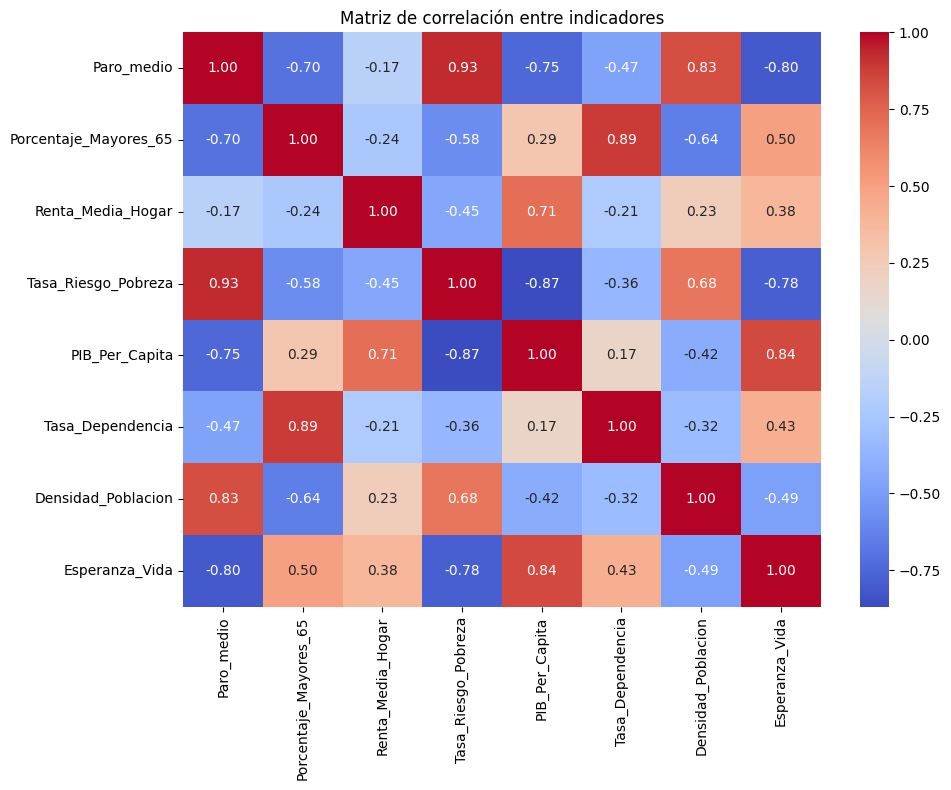

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre indicadores")
plt.tight_layout()
plt.show()

La matriz de correlación muestra relaciones especialmente intensas entre algunas variables. Destaca la correlación positiva entre tasa de paro y riesgo de pobreza, lo que indica que los territorios con mayores niveles de desempleo tienden también a presentar mayores niveles de vulnerabilidad social.

También se observa una relación negativa entre PIB per cápita y riesgo de pobreza, así como entre PIB per cápita y tasa de paro. Esto sugiere que las comunidades con mayor nivel de producción por habitante suelen presentar mejores condiciones laborales y menores tasas de pobreza.

Desde el punto de vista demográfico, el porcentaje de población mayor de 65 años presenta una fuerte relación positiva con la tasa de dependencia, lo que confirma la coherencia interna de ambos indicadores. Además, la densidad de población muestra una relación negativa con el envejecimiento, reflejando que las regiones menos densamente pobladas tienden a presentar una estructura demográfica más envejecida.

Por último, la esperanza de vida aparece positivamente relacionada con el PIB per cápita y negativamente relacionada con la tasa de paro y el riesgo de pobreza, lo que apunta a una posible conexión entre desarrollo socioeconómico y bienestar general de la población.

## Normalización de variables

Los indicadores seleccionados presentan escalas y unidades de medida muy diferentes. Por ejemplo, la tasa de paro se expresa en porcentaje, mientras que la renta media del hogar se mide en euros. Estas diferencias de escala pueden provocar que algunas variables dominen artificialmente el análisis.

Para evitar que las variables con valores absolutos más elevados dominen el análisis estadístico, se aplicó una normalización mediante estandarización (StandardScaler). Este procedimiento transforma cada variable para que tenga media cero y desviación típica uno.

La normalización resulta especialmente necesaria para la aplicación posterior de técnicas multivariantes como el análisis de componentes principales (PCA) y los algoritmos de agrupamiento.

In [ ]:
# Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=cols_modelo,
    index=df["Nombre_Completo"]
)

display(df_scaled)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Nombre_Completo,,,,,,,,
Andalucía,0.725112,-0.419325,-1.172080,0.858240,-1.020377,-0.501944,-0.371024,-0.994792
Aragón,-0.675589,0.409395,0.221135,-0.838605,0.876400,0.491022,-0.410555,0.607566
Principado de Asturias,-0.521687,1.785022,-0.402717,-0.405368,-0.221849,1.652054,-0.372887,-0.430582
Illes Balears,-0.500258,-0.966232,1.137227,-1.079292,0.781850,-1.561793,-0.286115,-0.272603
Canarias,0.391983,-0.643820,-0.371463,0.280591,-0.814582,-1.860197,-0.256398,-1.028645
Cantabria,-0.811958,0.867937,-0.168722,-0.802502,-0.185495,0.705393,-0.364004,0.212618
Castilla y León,-0.576235,1.519928,-0.779788,-0.092475,-0.030408,1.660629,-0.412306,1.092787
Castilla - La Mancha,0.245874,-0.192442,-1.086640,0.641621,-0.747492,-0.167525,-0.411587,0.167481
Cataluña,-0.613249,-0.278419,1.021954,-0.754364,0.997787,-0.452210,-0.284645,0.607566


Tras la normalización, las variables seleccionadas para el análisis multivariante presentan media cero y desviación típica uno, permitiendo compararlas en igualdad de condiciones.

## Análisis de Componentes Principales (PCA)

Con el objetivo de reducir la dimensionalidad del conjunto de datos y explorar la existencia de patrones conjuntos entre variables, se aplicó un Análisis de Componentes Principales (PCA).

Esta técnica permite transformar un conjunto de variables correlacionadas en un número menor de componentes sintéticos que concentran la mayor parte de la información contenida en los datos originales.

In [ ]:
# PCA
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(df_scaled)

varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza_explicada": pca.explained_variance_ratio_,
    "Varianza_acumulada": pca.explained_variance_ratio_.cumsum()
})

display(varianza)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.597306,0.597306
1,PC2,0.251150,0.848456
2,PC3,0.100348,0.948804
3,PC4,0.034243,0.983047
4,PC5,0.007881,0.990928
5,PC6,0.004595,0.995523
6,PC7,0.002891,0.998414
7,PC8,0.001586,1.000000


Los resultados muestran que el primer componente principal explica aproximadamente el 59,7% de la variabilidad total del conjunto de datos. Al incorporar el segundo componente, la varianza explicada acumulada alcanza el 84,8%.

Considerando los tres primeros componentes principales, se consigue representar cerca del 95% de la información original, lo que indica que gran parte de las diferencias entre comunidades autónomas puede resumirse mediante un número reducido de dimensiones sintéticas.

Aunque los tres primeros componentes explican conjuntamente el 94,9% de la varianza total, se optó por representar únicamente los dos primeros componentes principales, ya que concentran el 84,8% de la información original y permiten una visualización bidimensional fácilmente interpretable.

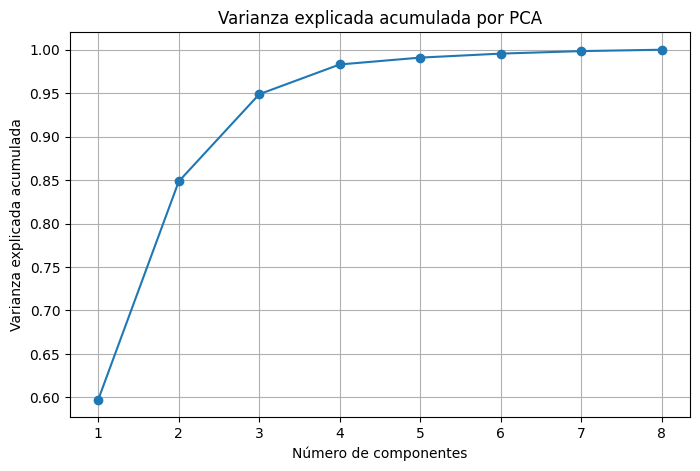

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.grid(True)
plt.show()

In [ ]:
# PCA en 2D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(df_scaled)

df_pca = pd.DataFrame({
    "Comunidad": df["Nombre_Completo"],
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1]
})

display(df_pca)

,Comunidad,PC1,PC2
0,Andalucía,1.765834,-1.091757
1,Aragón,-1.668791,0.198237
2,Principado de Asturias,-1.269410,-1.886980
3,Illes Balears,-0.374191,2.109946
4,Canarias,1.675549,0.248813
5,Cantabria,-1.305541,-0.797622
6,Castilla y León,-1.716249,-1.771956
7,Castilla - La Mancha,0.704382,-0.984942
8,Cataluña,-1.225969,1.451080
9,Comunitat Valenciana,0.733164,-0.813627


El primer componente principal parece estar asociado principalmente a factores de vulnerabilidad socioeconómica. Presenta cargas positivas elevadas en variables como la tasa de paro y el riesgo de pobreza, mientras que muestra cargas negativas en indicadores como el PIB per cápita y la esperanza de vida.

Por ello, valores elevados de este componente pueden interpretarse como territorios con mayores dificultades socioeconómicas, mientras que valores bajos se asocian a comunidades con mejores indicadores económicos y sociales.

El segundo componente principal refleja principalmente un contraste entre tamaño económico y envejecimiento demográfico. Las comunidades con mayores niveles de actividad económica y población tienden a situarse en los valores positivos de este eje, mientras que los territorios más envejecidos aparecen en valores negativos.

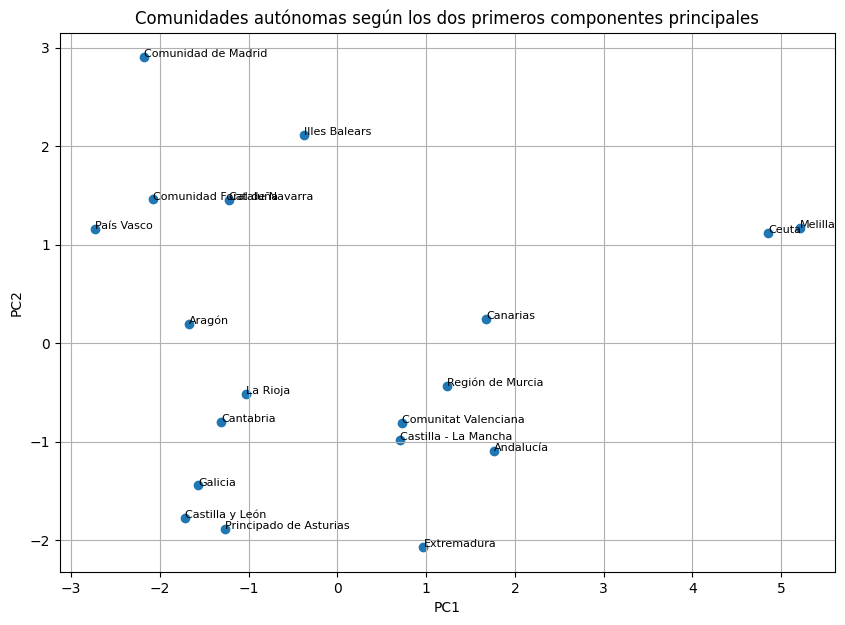

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(df_pca["PC1"], df_pca["PC2"])

for i, row in df_pca.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Comunidad"], fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Comunidades autónomas según los dos primeros componentes principales")
plt.grid(True)
plt.show()

In [ ]:
# Cargas de PCA
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=cols_modelo
)

display(loadings.sort_values("PC1", ascending=False))

,PC1,PC2
Paro_medio,0.442953,0.033762
Tasa_Riesgo_Pobreza,0.432059,-0.150141
Densidad_Poblacion,0.341346,0.238464
Renta_Media_Hogar,-0.124716,0.631709
Tasa_Dependencia,-0.261075,-0.414725
Porcentaje_Mayores_65,-0.341685,-0.420926
PIB_Per_Capita,-0.375348,0.385353
Esperanza_Vida,-0.399063,0.150746


La representación de las comunidades autónomas en el espacio definido por los dos primeros componentes principales permite identificar agrupaciones territoriales coherentes con los patrones observados previamente.

Por un lado, Madrid, Cataluña, País Vasco y Navarra aparecen asociadas a mejores indicadores económicos y sociales. En el extremo opuesto se sitúan Andalucía, Extremadura, Canarias y Murcia, caracterizadas por mayores niveles de desempleo y riesgo de pobreza.

Asimismo, Galicia, Asturias y Castilla y León conforman un grupo diferenciado por su elevado envejecimiento y dependencia demográfica.

Finalmente, Ceuta y Melilla aparecen claramente separadas del resto de territorios, actuando como casos atípicos dentro del conjunto analizado.

## Biplot de componentes principales

Además de representar las comunidades autónomas en el espacio definido por los dos primeros componentes principales, se construye un biplot que incorpora simultáneamente las variables originales.

Las flechas representan la dirección e intensidad de la contribución de cada variable a los componentes principales, permitiendo interpretar qué factores explican la posición relativa de cada territorio.

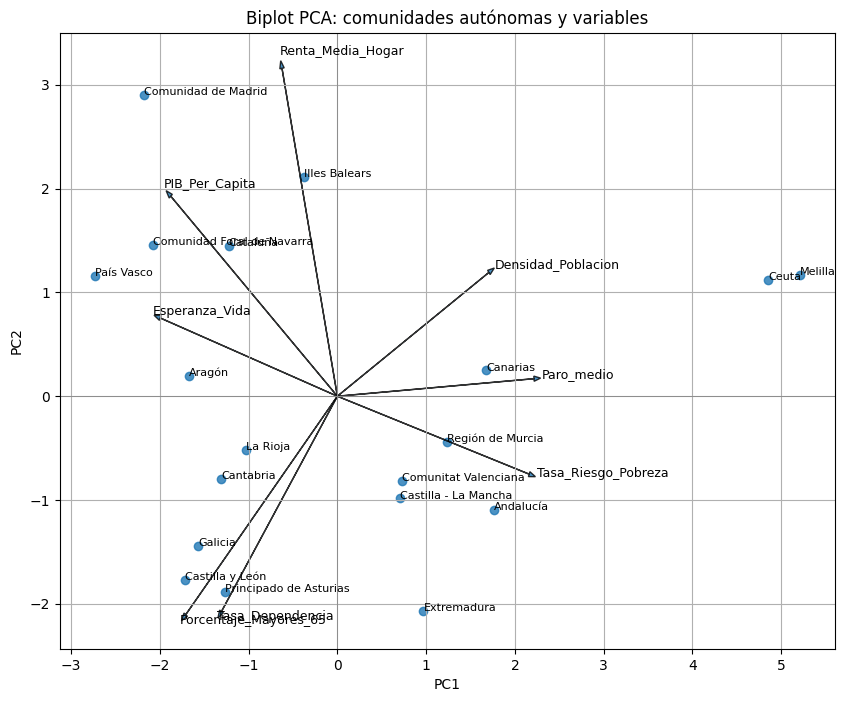

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

# Comunidades autónomas
ax.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.8
)

for _, row in df_pca.iterrows():
    ax.text(
        row["PC1"],
        row["PC2"],
        row["Comunidad"],
        fontsize=8
    )

# Flechas variables
for variable in loadings.index:

    ax.arrow(
        0,
        0,
        loadings.loc[variable, "PC1"] * 5,
        loadings.loc[variable, "PC2"] * 5,
        head_width=0.05,
        alpha=0.8
    )

    ax.text(
        loadings.loc[variable, "PC1"] * 5.2,
        loadings.loc[variable, "PC2"] * 5.2,
        variable,
        fontsize=9
    )

ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.set_title(
    "Biplot PCA: comunidades autónomas y variables"
)

plt.grid(True)
plt.show()

## Clustering
Con el objetivo de identificar tipologías territoriales de forma automática, se aplicó el algoritmo de agrupamiento K-Means sobre las variables previamente normalizadas.

Este procedimiento permite agrupar comunidades autónomas con características socioeconómicas similares sin imponer categorías previas. De este modo, los grupos obtenidos emergen directamente de los datos analizados.

Para determinar el número adecuado de agrupaciones se evaluaron diferentes configuraciones utilizando el coeficiente de Silhouette, seleccionándose aquella que ofrecía el mejor equilibrio entre cohesión interna y separación entre grupos.

In [ ]:
# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_k = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    resultados_k.append({"k": k, "silhouette": score})

df_k = pd.DataFrame(resultados_k)
display(df_k)

,k,silhouette
0,2,0.382120
1,3,0.413408
2,4,0.455697
3,5,0.422852
4,6,0.372431


La evaluación mediante el coeficiente de Silhouette mostró que la configuración de cuatro grupos presentaba el mejor resultado (0,397), por lo que se seleccionó como solución final para el análisis.

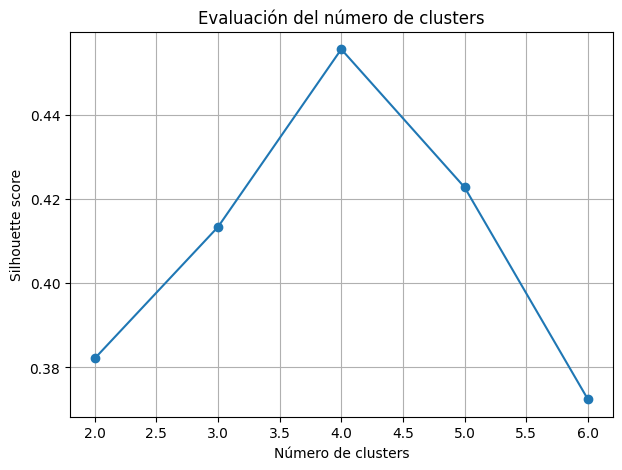

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(df_k["k"], df_k["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación del número de clusters")
plt.grid(True)
plt.show()

In [ ]:
k_optimo = 4

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

display(df[["Nombre_Completo", "Cluster"]].sort_values("Cluster"))

,Nombre_Completo,Cluster
1,Aragón,0
2,Principado de Asturias,0
6,Castilla y León,0
5,Cantabria,0
11,Galicia,0
16,La Rioja,0
7,Castilla - La Mancha,1
4,Canarias,1
10,Extremadura,1
9,Comunitat Valenciana,1


1. El primer grupo reúne comunidades caracterizadas por niveles relativamente elevados de desempleo y riesgo de pobreza, acompañados de menores niveles de renta y PIB per cápita. Aunque presentan situaciones internas diversas, comparten una posición menos favorable en numerosos indicadores económicos y sociales.
2. El segundo grupo está formado únicamente por Madrid y Cataluña, territorios que concentran una parte muy importante de la actividad económica española Presentan los mayores valores de PIB, renta y PIB per cápita del conjunto analizado, constituyendo los principales motores económicos del país.
3. El tercer grupo agrupa comunidades con niveles relativamente elevados de bienestar económico y bajas tasas de desempleo, aunque acompañados de procesos más intensos de envejecimiento y dependencia demográfica. En este conjunto predominan las regiones del norte peninsular junto con otros territorios que presentan características socioeconómicas similares.
4. El cuarto grupo está formado exclusivamente por Ceuta y Melilla. Sus características demográficas, económicas y territoriales difieren significativamente del resto de comunidades autónomas, lo que provoca su aislamiento en una categoría propia dentro del proceso de agrupamiento.

In [ ]:
# Interpretación clusters
perfil_clusters = df.groupby("Cluster")[cols_modelo].mean()
display(perfil_clusters)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Cluster,,,,,,,,
0,8.205,25.350000,37266.333333,16.483333,31909.166667,60.731667,69.656667,84.018333
1,13.325,19.626667,33826.000000,25.900000,26081.333333,51.510000,138.000000,83.230000
2,24.590,13.185000,41633.000000,38.150000,22094.000000,48.980000,5716.965000,82.130000
3,8.058,20.120000,45678.800000,12.040000,39685.000000,52.578000,353.054000,84.516000


In [ ]:
df_scaled_clusters = df_scaled.copy()
df_scaled_clusters["Cluster"] = df["Cluster"].values

perfil_clusters_scaled = df_scaled_clusters.groupby("Cluster").mean()
display(perfil_clusters_scaled)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Cluster,,,,,,,,
0,-0.643445,1.066162,-0.322080,-0.491614,0.129074,1.079541,-0.387517,0.357432
1,0.353995,-0.300709,-1.020277,0.641621,-0.780205,-0.501944,-0.349168,-0.532140
2,2.548556,-1.839135,0.564111,2.115830,-1.402323,-0.935830,2.781300,-1.773403
3,-0.672082,-0.182889,1.385185,-1.026341,1.342286,-0.318785,-0.228497,0.919010


## Visualización de clusters

Una vez obtenidas las tipologías territoriales mediante K-Means, se representa su distribución espacial sobre un mapa de comunidades autónomas. Para ello se utiliza GeoPandas, que permite trabajar con datos geográficos en formato GeoJSON y unirlos con los resultados del análisis.

In [ ]:
!pip install geopandas

Se carga un archivo GeoJSON con las geometrías de las comunidades y ciudades autónomas españolas. Este archivo contiene los polígonos necesarios para representar cada territorio en un mapa.

El conjunto geográfico utilizado procede del repositorio abierto `click_that_hood`, que proporciona geometrías administrativas en formato GeoJSON para distintos países y regiones.

In [ ]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"

gdf = gpd.read_file(url)

gdf.head()

,cod_ccaa,noml_ccaa,name,cartodb_id,created_at,updated_at,geometry
0,07,COMUNIDAD DE CASTILLA Y LEON,Castilla-Leon,7,2014-09-30 00:00:00+00:00,2014-12-25 02:07:41+00:00,"MULTIPOLYGON (((-4.89358 43.23848, -4.8392 43...."
1,09,COMUNIDAD AUTONOMA DE CATALUÑA,Cataluña,8,2014-09-30 00:00:00+00:00,2014-12-25 02:07:41+00:00,"MULTIPOLYGON (((0.71604 42.85832, 0.85552 42.8..."
2,18,CIUDAD DE CEUTA,Ceuta,9,2014-09-30 00:00:00+00:00,2014-12-25 02:07:41+00:00,"MULTIPOLYGON (((-5.34496 35.87106, -5.37291 35..."
3,14,COMUNIDAD AUTONOMA DE LA REGION DE MURCI,Murcia,15,2014-09-30 00:00:00+00:00,2014-12-25 02:07:41+00:00,"MULTIPOLYGON (((-1.14985 38.74607, -1.11967 38..."
4,17,COMUNIDAD AUTONOMA DE LA RIOJA,La Rioja,12,2014-09-30 00:00:00+00:00,2014-12-25 02:07:41+00:00,"MULTIPOLYGON (((-2.99723 42.64214, -2.94645 42..."


Antes de unir los resultados del clustering con el mapa, se revisan los nombres de las comunidades autónomas incluidos en el GeoJSON. Esta comprobación es necesaria porque los nombres pueden no coincidir exactamente con los utilizados en las tablas del INE.

In [ ]:
print(gdf.columns)

gdf["name"]

Index(['cod_ccaa', 'noml_ccaa', 'name', 'cartodb_id', 'created_at',
       'updated_at', 'geometry'],
      dtype='object')


,name
0,Castilla-Leon
1,Cataluña
2,Ceuta
3,Murcia
4,La Rioja
5,Baleares
6,Canarias
7,Cantabria
8,Andalucia
9,Asturias


Se crea una tabla auxiliar que contiene únicamente el nombre normalizado de cada comunidad autónoma y el cluster asignado por el algoritmo K-Means. Esta tabla será utilizada para unir los resultados del análisis con la geometría territorial.

In [ ]:
cluster_df = df[["Nombre_Completo", "Cluster"]].copy()

Los nombres de las comunidades autónomas no coinciden exactamente entre el dataset analítico y el archivo GeoJSON. Por este motivo, se define un diccionario de equivalencias que permite adaptar los nombres del conjunto de datos al formato utilizado en el mapa.

Esta armonización es necesaria para realizar correctamente la unión entre los resultados del clustering y las geometrías territoriales.

In [ ]:
equivalencias = {
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Principado de Asturias": "Asturias",
    "Illes Balears": "Baleares",
    "Comunitat Valenciana": "Valencia",
    "Comunidad de Madrid": "Madrid",
    "Comunidad Foral de Navarra": "Navarra",
    "Región de Murcia": "Murcia",
    "País Vasco": "Pais Vasco",
    "Castilla y León": "Castilla-Leon",
    "Castilla - La Mancha": "Castilla-La Mancha"
}

cluster_df["Mapa"] = cluster_df["Nombre_Completo"].replace(equivalencias)

Una vez armonizados los nombres, se realiza una unión entre el GeoJSON de comunidades autónomas y la tabla de clusters. El resultado es un GeoDataFrame que contiene tanto la geometría de cada territorio como la tipología asignada por el modelo de clustering.

In [ ]:
gdf_merge = gdf.merge(
    cluster_df,
    left_on="name",
    right_on="Mapa",
    how="left"
)

La tabla resultante permite comprobar que cada comunidad autónoma ha sido asociada correctamente con su cluster correspondiente. Esta verificación evita errores en la representación cartográfica derivados de problemas de nomenclatura.

In [ ]:
gdf_merge[["name","Cluster"]]

,name,Cluster
0,Castilla-Leon,0
1,Cataluña,3
2,Ceuta,2
3,Murcia,1
4,La Rioja,0
5,Baleares,3
6,Canarias,1
7,Cantabria,0
8,Andalucia,1
9,Asturias,0


Finalmente, se representa el resultado del clustering sobre el mapa de España. Cada color corresponde a uno de los grupos identificados por K-Means, permitiendo observar la distribución espacial de las tipologías territoriales obtenidas.

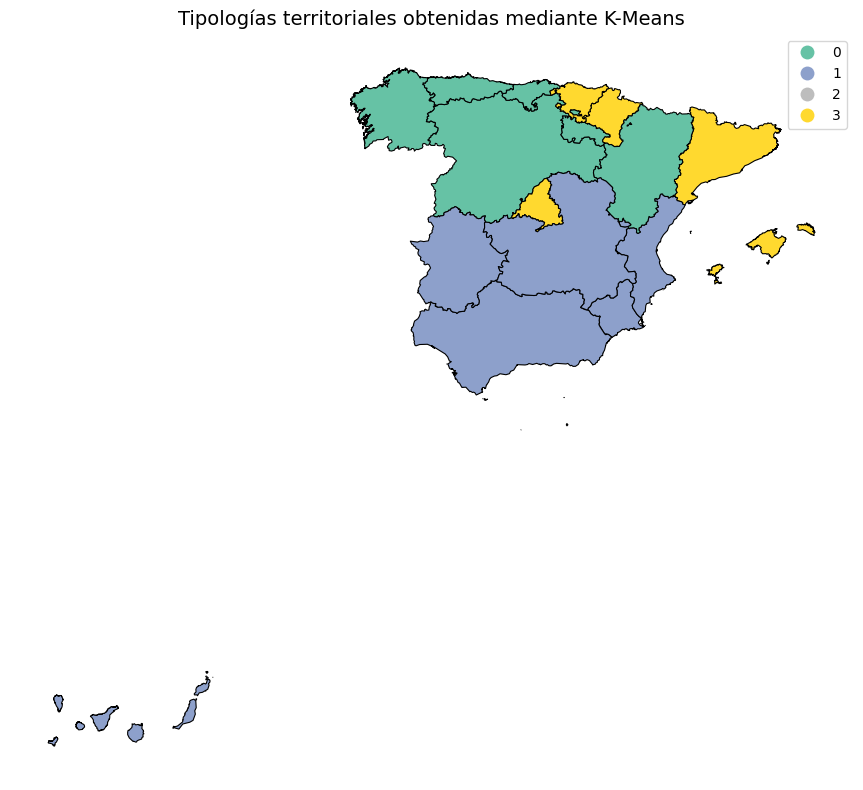

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Colores personalizados:
# Cluster 0 -> verde
# Cluster 1 -> azul
# Cluster 2 -> gris
# Cluster 3 -> amarillo
cmap = ListedColormap([
    "#66c2a5",  # 0
    "#8da0cb",  # 1
    "#bdbdbd",  # 2 (gris)
    "#ffd92f"   # 3 (amarillo)
])

fig, ax = plt.subplots(figsize=(10,8))

gdf_merge.plot(
    column="Cluster",
    categorical=True,
    cmap=cmap,
    #cmap="Set2",
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title(
    "Tipologías territoriales obtenidas mediante K-Means",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

El mapa muestra una distribución territorial coherente con los patrones observados en el análisis estadístico. Las regiones del sur y sureste peninsular aparecen agrupadas en un mismo cluster, mientras que Madrid y Cataluña forman un grupo propio asociado a los principales polos económicos del país.

Por su parte, gran parte de las regiones del norte y del interior septentrional se integran en otro cluster caracterizado por mejores indicadores socioeconómicos, aunque con mayor envejecimiento demográfico. Finalmente, Ceuta y Melilla aparecen como casos singulares debido a sus características territoriales y socioeconómicas específicas.

# Análisis de robustez: exclusión de Ceuta y Melilla

Con el objetivo de evaluar la estabilidad de las tipologías territoriales obtenidas, se realiza una prueba de robustez excluyendo temporalmente las ciudades autónomas de Ceuta y Melilla.

Estas presentan características demográficas y socioeconómicas muy diferenciadas respecto al resto de territorios analizados, especialmente en variables relacionadas con el desempleo, el riesgo de pobreza, la densidad de población y la estructura demográfica.

El análisis permite comprobar si los patrones detectados mediante PCA y clustering K-Means se mantienen estables o si dichas observaciones extremas influyen significativamente en la formación de los grupos.

In [ ]:
df_robustez = df[~df["Nombre_Completo"].isin(["Ceuta", "Melilla"])].copy()

print("Número de territorios:", len(df_robustez))

display(df_robustez[["Nombre_Completo"]])

Número de territorios: 17


,Nombre_Completo
0,Andalucía
1,Aragón
2,Principado de Asturias
3,Illes Balears
4,Canarias
5,Cantabria
6,Castilla y León
7,Castilla - La Mancha
8,Cataluña
9,Comunitat Valenciana


In [ ]:
X_robustez = df_robustez[cols_modelo]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_robustez = StandardScaler()

X_robustez_scaled = scaler_robustez.fit_transform(X_robustez)

X_robustez_scaled = pd.DataFrame(
    X_robustez_scaled,
    columns=cols_modelo,
    index=df_robustez["Nombre_Completo"]
)

display(X_robustez_scaled.head())

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,Tasa_Riesgo_Pobreza,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Nombre_Completo,,,,,,,,
Andalucía,1.997143,-0.775936,-1.068093,1.525477,-1.280926,-0.614650,-0.387021,-1.479030
Aragón,-0.732181,0.235610,0.277719,-0.812482,0.768780,0.382548,-0.736221,0.490291
Principado de Asturias,-0.432297,1.914717,-0.324907,-0.215557,-0.418016,1.548529,-0.403477,-0.785607
Illes Balears,-0.390541,-1.443497,1.162642,-1.144108,0.666606,-1.679016,0.363030,-0.591449
Canarias,1.348027,-1.049957,-0.294717,0.729576,-1.058539,-1.978692,0.625538,-1.520635


Al igual que en el análisis principal, se aplica Análisis de Componentes Principales (PCA) sobre los datos normalizados con el fin de reducir la dimensionalidad y sintetizar la información contenida en las variables originales.

Posteriormente se compara la varianza explicada con la obtenida en el análisis completo para comprobar la estabilidad de la estructura interna de los datos.

In [ ]:
from sklearn.decomposition import PCA

pca_robustez = PCA()

X_pca_robustez = pca_robustez.fit_transform(X_robustez_scaled)

varianza_robustez = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca_robustez.explained_variance_ratio_))],
    "Varianza_explicada": pca_robustez.explained_variance_ratio_,
    "Varianza_acumulada": pca_robustez.explained_variance_ratio_.cumsum()
})

display(varianza_robustez)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.560139,0.560139
1,PC2,0.307816,0.867955
2,PC3,0.069376,0.937331
3,PC4,0.037180,0.974511
4,PC5,0.014503,0.989014
5,PC6,0.006067,0.995081
6,PC7,0.003493,0.998574
7,PC8,0.001426,1.000000


Se comparan los resultados del PCA original y del PCA sin Ceuta y Melilla para comprobar si la estructura de los componentes principales se mantiene estable tras eliminar dichas observaciones.

In [ ]:
print("PCA original")
display(varianza.head(3))

print("PCA sin Ceuta y Melilla")
display(varianza_robustez.head(3))

PCA original


,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.597306,0.597306
1,PC2,0.251150,0.848456
2,PC3,0.100348,0.948804


PCA sin Ceuta y Melilla


,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.560139,0.560139
1,PC2,0.307816,0.867955
2,PC3,0.069376,0.937331


Se evalúan diferentes particiones mediante el coeficiente Silhouette con el fin de identificar el número de grupos que mejor representa la estructura de los datos tras excluir las ciudades autónomas.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_robustez = []

for k in range(2,7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_robustez_scaled)

    score = silhouette_score(
        X_robustez_scaled,
        labels
    )

    resultados_robustez.append({
        "k": k,
        "silhouette": score
    })

df_robustez_k = pd.DataFrame(resultados_robustez)

display(df_robustez_k)

,k,silhouette
0,2,0.403047
1,3,0.415086
2,4,0.393680
3,5,0.375318
4,6,0.272171


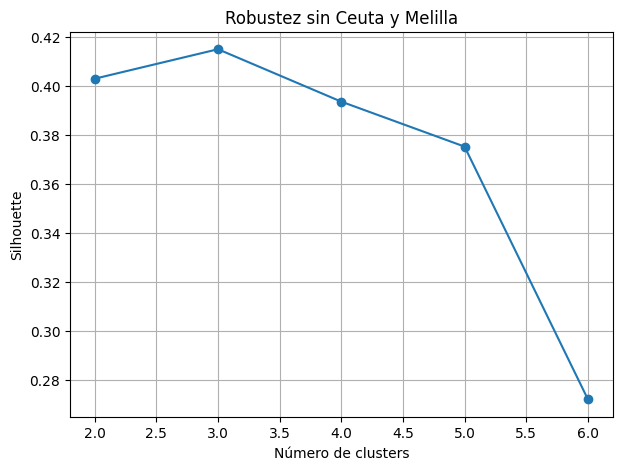

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    df_robustez_k["k"],
    df_robustez_k["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.title("Robustez sin Ceuta y Melilla")

plt.grid(True)

plt.show()

Una vez identificado el número óptimo de grupos, se aplica nuevamente el algoritmo K-Means para obtener las tipologías territoriales resultantes y compararlas con las obtenidas en el análisis principal.

In [ ]:
kmeans_robustez = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_robustez["Cluster"] = kmeans_robustez.fit_predict(
    X_robustez_scaled
)

display(
    df_robustez[
        ["Nombre_Completo","Cluster"]
    ].sort_values("Cluster")
)

,Nombre_Completo,Cluster
1,Aragón,0
2,Principado de Asturias,0
6,Castilla y León,0
5,Cantabria,0
11,Galicia,0
16,La Rioja,0
7,Castilla - La Mancha,1
4,Canarias,1
10,Extremadura,1
9,Comunitat Valenciana,1


In [ ]:
cluster_df_rob = df_robustez[
    ["Nombre_Completo","Cluster"]
].copy()

equivalencias = {
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Principado de Asturias": "Asturias",
    "Illes Balears": "Baleares",
    "Comunitat Valenciana": "Valencia",
    "Comunidad de Madrid": "Madrid",
    "Comunidad Foral de Navarra": "Navarra",
    "Región de Murcia": "Murcia",
    "País Vasco": "Pais Vasco",
    "Castilla y León": "Castilla-Leon",
    "Castilla - La Mancha": "Castilla-La Mancha"
}

cluster_df_rob["Mapa"] = cluster_df_rob[
    "Nombre_Completo"
].replace(equivalencias)

gdf_rob = gdf.merge(
    cluster_df_rob,
    left_on="name",
    right_on="Mapa",
    how="left"
)

La siguiente figura muestra la distribución geográfica de los grupos obtenidos tras excluir Ceuta y Melilla. Esto permite visualizar de forma intuitiva si la estructura territorial detectada se mantiene estable respecto al análisis inicial.

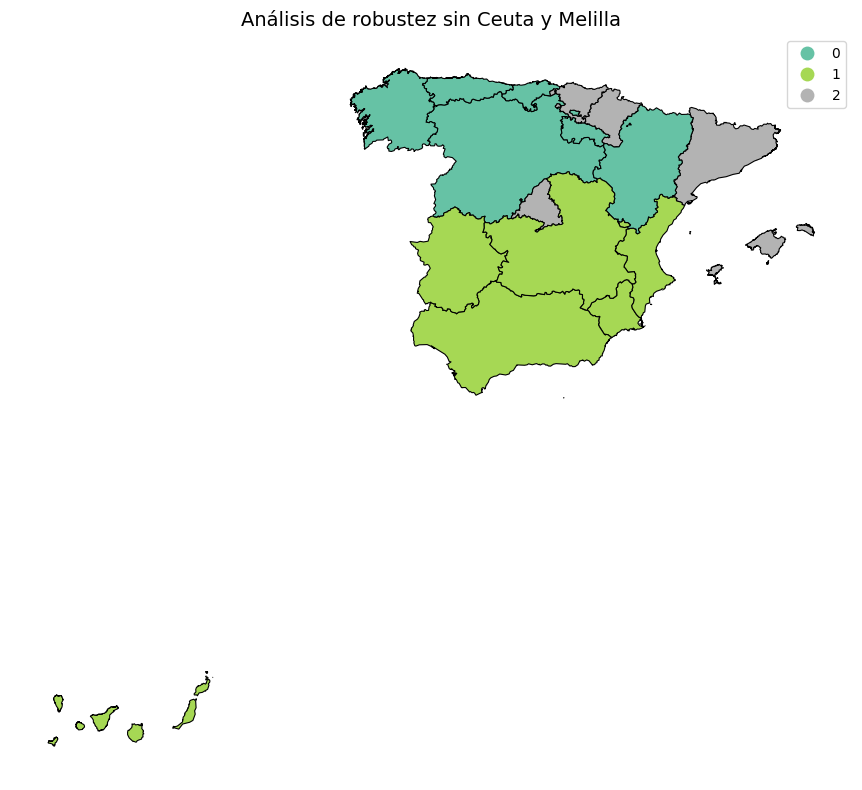

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

gdf_rob["Cluster"] = gdf_rob["Cluster"].astype("Int64")

gdf_rob.plot(
    column="Cluster",
    categorical=True,
    cmap="Set2",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Análisis de robustez sin Ceuta y Melilla",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

Los resultados muestran que la exclusión de Ceuta y Melilla no altera sustancialmente la estructura territorial detectada por el modelo.

Las comunidades autónomas continúan agrupándose en tres grandes bloques diferenciados:

- Territorios del norte e interior caracterizados por elevados niveles de envejecimiento.
- Territorios del sur y periferia mediterránea con mayores dificultades socioeconómicas.
- Territorios con mayor dinamismo económico y mejores indicadores de renta y empleo.

Esto refuerza la validez de las tipologías obtenidas y sugiere que los patrones identificados no dependen exclusivamente de observaciones extremas.